## 3.1 Contents<a id='3.1_Contents'></a>
* [3 Exploratory Data Analysis (EDA)](#3_Exploratory_Data_Analysis_(EDA))
  * [3.1 Contents](#3.1_Contents)
  * [3.2 Introduction](#3.2_Introduction)
  * [3.3 Objectives](#3.3_Objectives)
  * [3.4 Imports](#3.4_Imports)
  * [3.5 Load The Data](#3.5_Load_The_Data)
    * [3.5.1 EV County Year data](#3.5.1_EV_County_Year_data)
  * [3.6 Explore The Data](#3.6_Explore_The_Data)
    * [3.6.1 EV County Year Data Analysis](#3.6.1_EV_County_Year_Data_Analysis)
      * [3.6.1.1 Univariate Analysis](#3.6.1.1_Univariate_Analysis)
      * [3.6.1.2 Bivariate_Analysis](#3.6.1.2_Bivariate_Analysis)
      * [3.6.1.3 Time Trends](#3.6.1.3_Time_Trends)
        * [3.6.1.3.1 Feature Trends](#3.6.1.3.1_Feature_Trends)
        * [3.6.1.3.2 County Trends](#3.6.1.3.1_County_Trends)
      * [3.6.1.4 Correlation Analysis](#3.6.1.4_Correlation_Analysis)
      * [3.6.1.5 Segmentation Analysis](#3.6.1.5_Segmentation_Analysis)
      * [3.6.1.6 Model Readiness Checks](#3.6.1.7_Model_Readiness_Checks)
  * [3.7 Summary](#3.7_Summary)

## 3.2 Introduction<a id='3.2_Introduction'></a>

The core problem we are trying to model for is what drives EV adoption rate across counties and identify patterns to inform strategic decisions such as prioritizing particular counties for EV infrastructure and policy incentives. 

In the previous data wrangling step, we cleaned and merged multiple datasets including EV population data, Total passenger vehicle registration data, socioeconomic and EV charging stations data into one unified dataset at county/year level from 2017 to 2025. We also created our target variable of EV adoption rate with EV registrations as the numerator and total passenger vehicle registrations as our denominator.

This EDA phase will focus on exploring and uncovering features and target variable relationships and patterns that would potentially explain county disparities in EV adoption. It will also inform feature selection and modeling.

Next, we will import the needed python packages and load our cleaned EV dataset mentioned above and begin exploring them.

## 3.3 Objectives<a id='3.3_Objectives'></a>

 * Understand Feature & Target Variable Distributions
 * Understand Feature and Target Variable Relationships
 * Time Trends Analysis
 * Identify High/Low EV Adoption Regions
 * Identify key predictors & their quality for model readiness
 * Explore segmentation & predictive modeling

## 3.4 Imports<a id='3.4_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from library.sb_utils import save_file
imagepath = '../reports/figures'

## 3.5 Load The Data<a id='3.4_Load_The_Data'></a>

### 3.5.1 EV County Year data<a id='3.5.1_EV_County_Year_data'></a>

In [2]:
ev_adoption_df = pd.read_csv('../data/processed/final_ev_info_dataset.csv')

In [3]:
ev_adoption_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          351 non-null    int64  
 1   county                        351 non-null    object 
 2   total_registered_vehicles     351 non-null    int64  
 3   registered_electric_vehicles  351 non-null    int64  
 4   bev_ratio_within_ev           351 non-null    float64
 5   cafv_eligibility_rate         351 non-null    float64
 6   median_income                 351 non-null    int64  
 7   population                    351 non-null    int64  
 8   ev_charging_stations          351 non-null    int64  
 9   ev_adoption_rate              351 non-null    float64
 10  ev_growth_rate                351 non-null    float64
 11  has_growth                    351 non-null    int64  
 12  new_ev_purchase_ratio         351 non-null    float64
 13  ev_ad

In [4]:
ev_adoption_df.head()

,year,county,total_registered_vehicles,registered_electric_vehicles,bev_ratio_within_ev,cafv_eligibility_rate,median_income,population,ev_charging_stations,ev_adoption_rate,ev_growth_rate,has_growth,new_ev_purchase_ratio,ev_adoption_lag,lag_missing_flag,high_adoption,adoption_segment,income_per_vehicle,ev_charging_density,has_charging_infrastructure
0,2017,Adams,13160,5,0.000000,0.666667,48849,20068,1,0.037994,0.000000,0,60.000000,0.000000,1,0,low,3.711930,0.004983,1
1,2018,Adams,13742,4,1.000000,1.000000,52870,20200,1,0.029108,-33.333333,0,200.000000,0.037994,0,0,low,3.847329,0.004950,1
2,2019,Adams,13447,7,0.666667,0.666667,53535,20335,2,0.052056,40.000000,1,42.857143,0.029108,0,0,low,3.981185,0.009835,1
3,2020,Adams,13726,10,1.000000,1.000000,56421,20613,2,0.072854,25.000000,1,90.000000,0.052056,0,0,low,4.110520,0.009703,1
4,2021,Adams,13898,17,0.750000,0.750000,57405,20900,2,0.122320,54.545455,1,47.058824,0.072854,0,0,low,4.130450,0.009569,1


In [5]:
ev_adoption_df.describe()

,year,total_registered_vehicles,registered_electric_vehicles,bev_ratio_within_ev,cafv_eligibility_rate,median_income,population,ev_charging_stations,ev_adoption_rate,ev_growth_rate,has_growth,new_ev_purchase_ratio,ev_adoption_lag,lag_missing_flag,high_adoption,income_per_vehicle,ev_charging_density,has_charging_infrastructure
count,351.000000,3.510000e+02,351.000000,351.000000,351.000000,351.000000,3.510000e+02,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,2021.000000,1.328117e+05,2391.843305,0.716940,0.853012,69198.074074,1.989430e+05,32.943020,0.892993,30.571621,0.831909,49.239732,0.653472,0.111111,0.250712,4.358829,0.016208,0.888889
std,2.585675,2.605637e+05,9988.667343,0.188564,0.158142,15793.344797,4.002627e+05,126.133997,1.109072,26.674495,0.374481,38.404817,0.893526,0.314718,0.434042,8.069189,0.017088,0.314718
min,2017.000000,1.327000e+03,0.000000,0.000000,0.000000,42212.000000,2.263000e+03,0.000000,0.000000,-100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.059766,0.000000,0.000000
25%,2019.000000,1.536900e+04,45.000000,0.666667,0.820291,57758.000000,2.246100e+04,2.000000,0.187158,21.052632,1.000000,29.332028,0.106162,0.000000,0.000000,0.601555,0.004547,1.000000
50%,2021.000000,4.981100e+04,213.000000,0.763780,0.885344,65943.000000,6.575000e+04,8.000000,0.505474,34.615385,1.000000,41.401274,0.331135,0.000000,0.000000,1.436289,0.010577,1.000000
75%,2023.000000,1.428480e+05,877.500000,0.826876,0.933333,77989.000000,2.007765e+05,20.000000,1.152407,44.346843,1.000000,56.783537,0.829273,0.000000,0.500000,4.120485,0.022868,1.000000
max,2025.000000,1.503246e+06,113056.000000,1.000000,1.000000,126124.000000,2.411700e+06,1412.000000,7.584261,101.176471,1.000000,350.000000,6.437820,1.000000,1.000000,53.364732,0.113208,1.000000


Everything looks good so far. There are no nulls or inf values, data format and structure looks good for EDA Analysis.

## 3.6 Explore The Data<a id='3.6_Explore_The_Data'></a>

Let's start diving into Feature & Target Variable Distributions, Relationships, Time Trends and understand the patterns and potential predictors that drive EV adoption rates.

### 3.6.1 EV County Year Data Analysis<a id='3.6.1_EV_County_Year_Data_Analysis'></a>

#### 3.6.1.1 Univariate Analysis<a id='3.6.1.1_Univariate_Analysis'></a>

Lets look at the target variable and feature distributions and see if further modifications will be needed to our features prior to modeling.

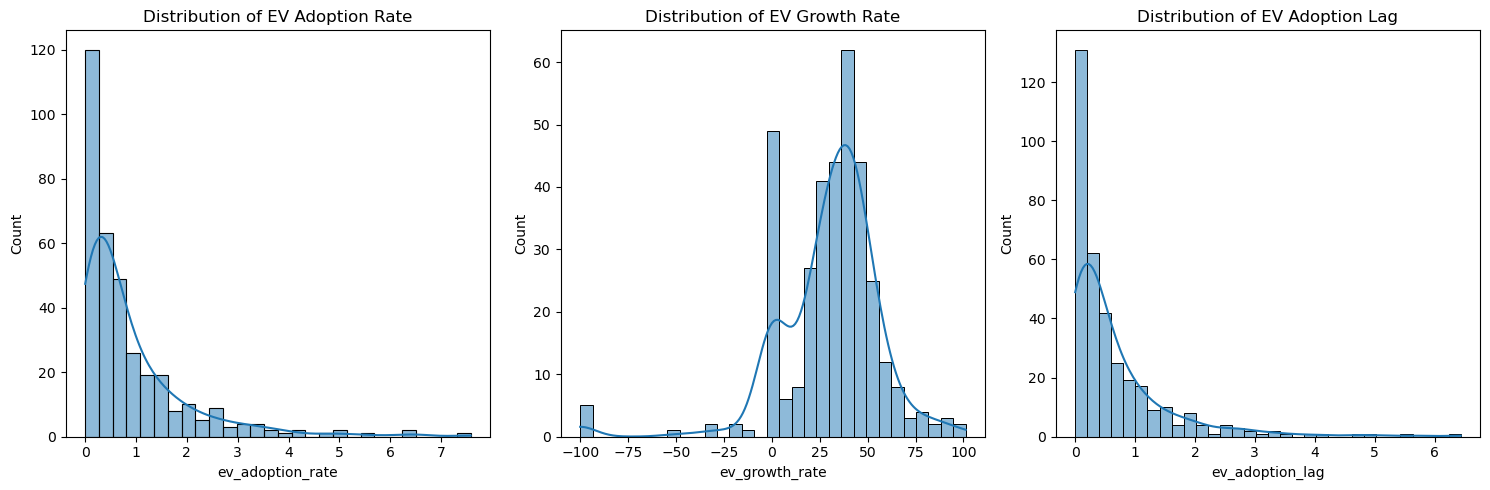

In [6]:
#Understanding distribution of target variable ev_adoption_rate and other ev adoption related features.

fig, axes = plt.subplots(1, 3, figsize = (15,5))
sns.histplot(ev_adoption_df['ev_adoption_rate'], ax = axes[0], kde=True )
axes[0].set_title(f"Distribution of EV Adoption Rate")
sns.histplot(ev_adoption_df['ev_growth_rate'], ax = axes[1], kde=True )
axes[1].set_title(f"Distribution of EV Growth Rate")
sns.histplot(ev_adoption_df['ev_adoption_lag'], ax = axes[2], kde=True )
axes[2].set_title(f"Distribution of EV Adoption Lag")
plt.tight_layout()
image_path_global_ev_related_distributions = os.path.join(imagepath, 'all_ev_adoption_related_distributions.png')
plt.savefig(image_path_global_ev_related_distributions, dpi = 300, bbox_inches='tight')
plt.show()

1. EV Adoption is a right tailed distribution and will probably need transformation for modeling.</p>
2. EV Growth Rate has a Volatile distribution (Bimodal with most counties experiencing 35 to 40% ev growth while many are also stagnant at 0, potentially small counties).</p>
3. EV Adoption Lag is a right tailed distribution and will probably need transformation for modeling.

Let us look at the distribution for socio economic features next.

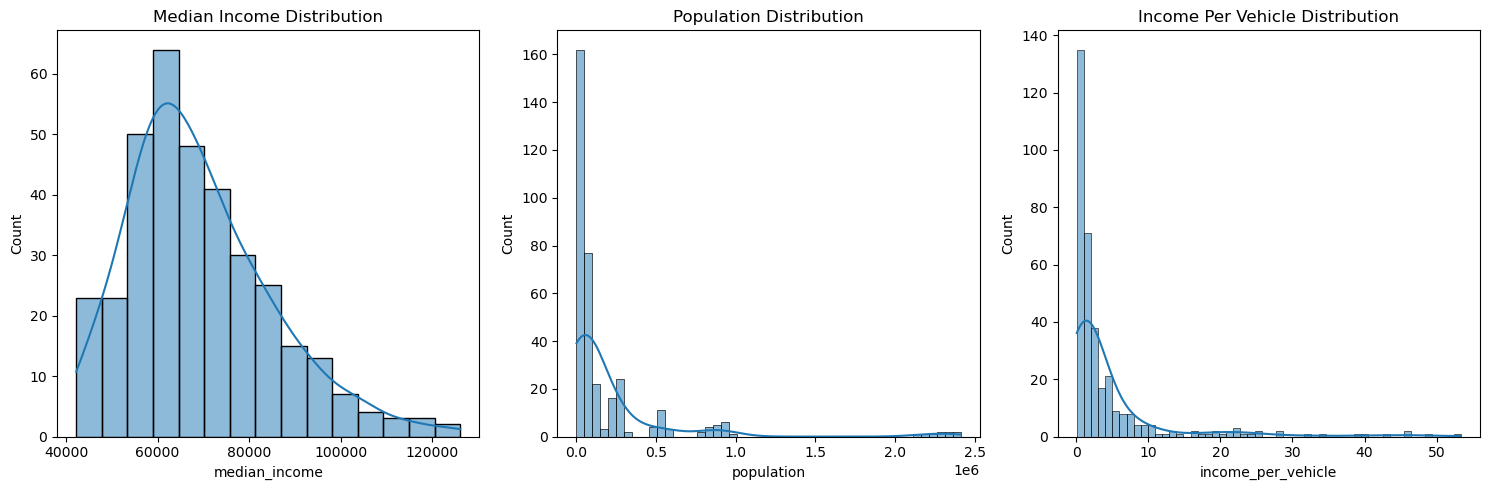

In [7]:
fig, axes = plt.subplots(1, 3, figsize = (15,5))
sns.histplot(ev_adoption_df['median_income'], ax = axes[0], kde=True)
axes[0].set_title('Median Income Distribution')
sns.histplot(ev_adoption_df['population'], ax = axes[1], kde=True)
axes[1].set_title('Population Distribution')
sns.histplot(ev_adoption_df['income_per_vehicle'], ax = axes[2], kde=True)
axes[2].set_title('Income Per Vehicle Distribution')
plt.tight_layout()
image_path_global_socioeconomic_distributions = os.path.join(imagepath, 'all_socioeconomic_distributions.png')
plt.savefig(image_path_global_socioeconomic_distributions, dpi = 300, bbox_inches='tight')
plt.show()

1. Median Income distribution has a slight right skewed normal distribution.</p>
2. Population distribution is right skewed because of a few urban counties with bigger populations. This will need log transformation.</p>
3. Income per Vehicle also is right skewed because because a few tiny rural counties with almost zero vehicle registrations create huge outlier ratios and distort this metric.</p>
Let's look at some of the EV infrastructure distributions next.

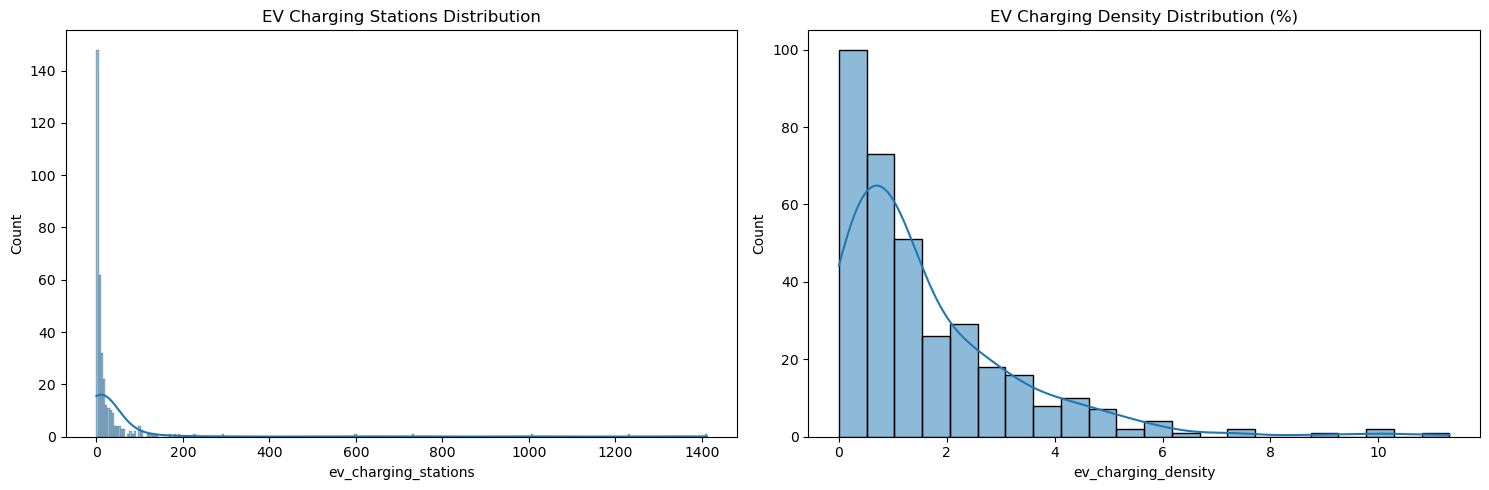

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (15,5))
sns.histplot(ev_adoption_df['ev_charging_stations'], ax = axes[0], kde=True)
axes[0].set_title('EV Charging Stations Distribution')
sns.histplot(100*ev_adoption_df['ev_charging_density'], ax = axes[1], kde=True)
axes[1].set_title('EV Charging Density Distribution (%)')
plt.tight_layout()
image_path_all_charging_distributions = os.path.join(imagepath, 'all_charging_distributions.png')
plt.savefig(image_path_all_charging_distributions, dpi = 300, bbox_inches='tight')
plt.show() 

Both EV Charging Stations and EV Charging Density Distributions are heavily right skewed pointing to a long tail of infrastructure heavy counties. Both will need log transformations.

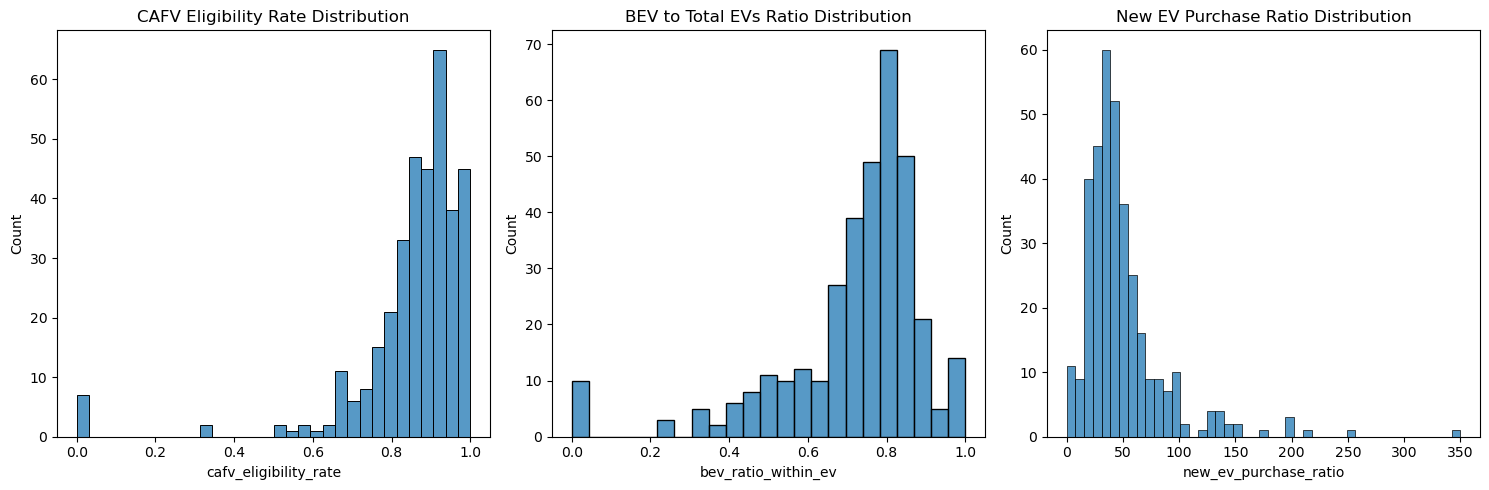

In [9]:
fig, axes = plt.subplots(1, 3, figsize = (15,5))
sns.histplot(ev_adoption_df['cafv_eligibility_rate'], ax = axes[0])
axes[0].set_title('CAFV Eligibility Rate Distribution')
sns.histplot(ev_adoption_df['bev_ratio_within_ev'], ax = axes[1])
axes[1].set_title('BEV to Total EVs Ratio Distribution')
sns.histplot(ev_adoption_df['new_ev_purchase_ratio'], ax = axes[2])
axes[2].set_title('New EV Purchase Ratio Distribution')
plt.tight_layout()
image_path_all_ev_feature_distributions = os.path.join(imagepath, 'all_ev_feature_distributions.png')
plt.savefig(image_path_all_ev_feature_distributions, dpi = 300, bbox_inches='tight')
plt.show()

1. CAFV (CLean Alternative Fuel Vehicle) Eligibility Rate : This distribution is left skewed indicating most of the values are clustered in high eligibility groups and very few in the 0 to low eligibility group.
2. BEV Share : BEV Share indicates the Battery Vehicle percentage of (BEV + PHEV (Plug In Hybrid)) Electric Vehicles. This distribution is left skewed indicating the dominance of BEV over PHEV vehicles.
3. New EV Purchase Ratio : This distribution is right skewed with the peak around 0.35 indicating 1/3 of the registered ev vehicles are new models. There are some extreme outliers >1 that could be due to data logging issues.

BEV share, CAFV Eligibility Rate which are vehicle technology features do not have too much of variability across counties. However, EV adoption rates significantly vary across counties. This suggests that vehicle technology features are not the primary drivers of EV adoption.

It looks like the observed variation is better explained by structural and socioeconomic factors such as income, population and availability of charging infrastructure. These factors seem to influence accessibility, affordability etc. of EV Vehicle ownwership.

#### 3.6.1.2 Bivariate Analysis<a id='3.6.1.2_Bivariate_Analysis'></a>

Let us look at the relationship of some of the key features with our target variable, ev_adoption_rate.

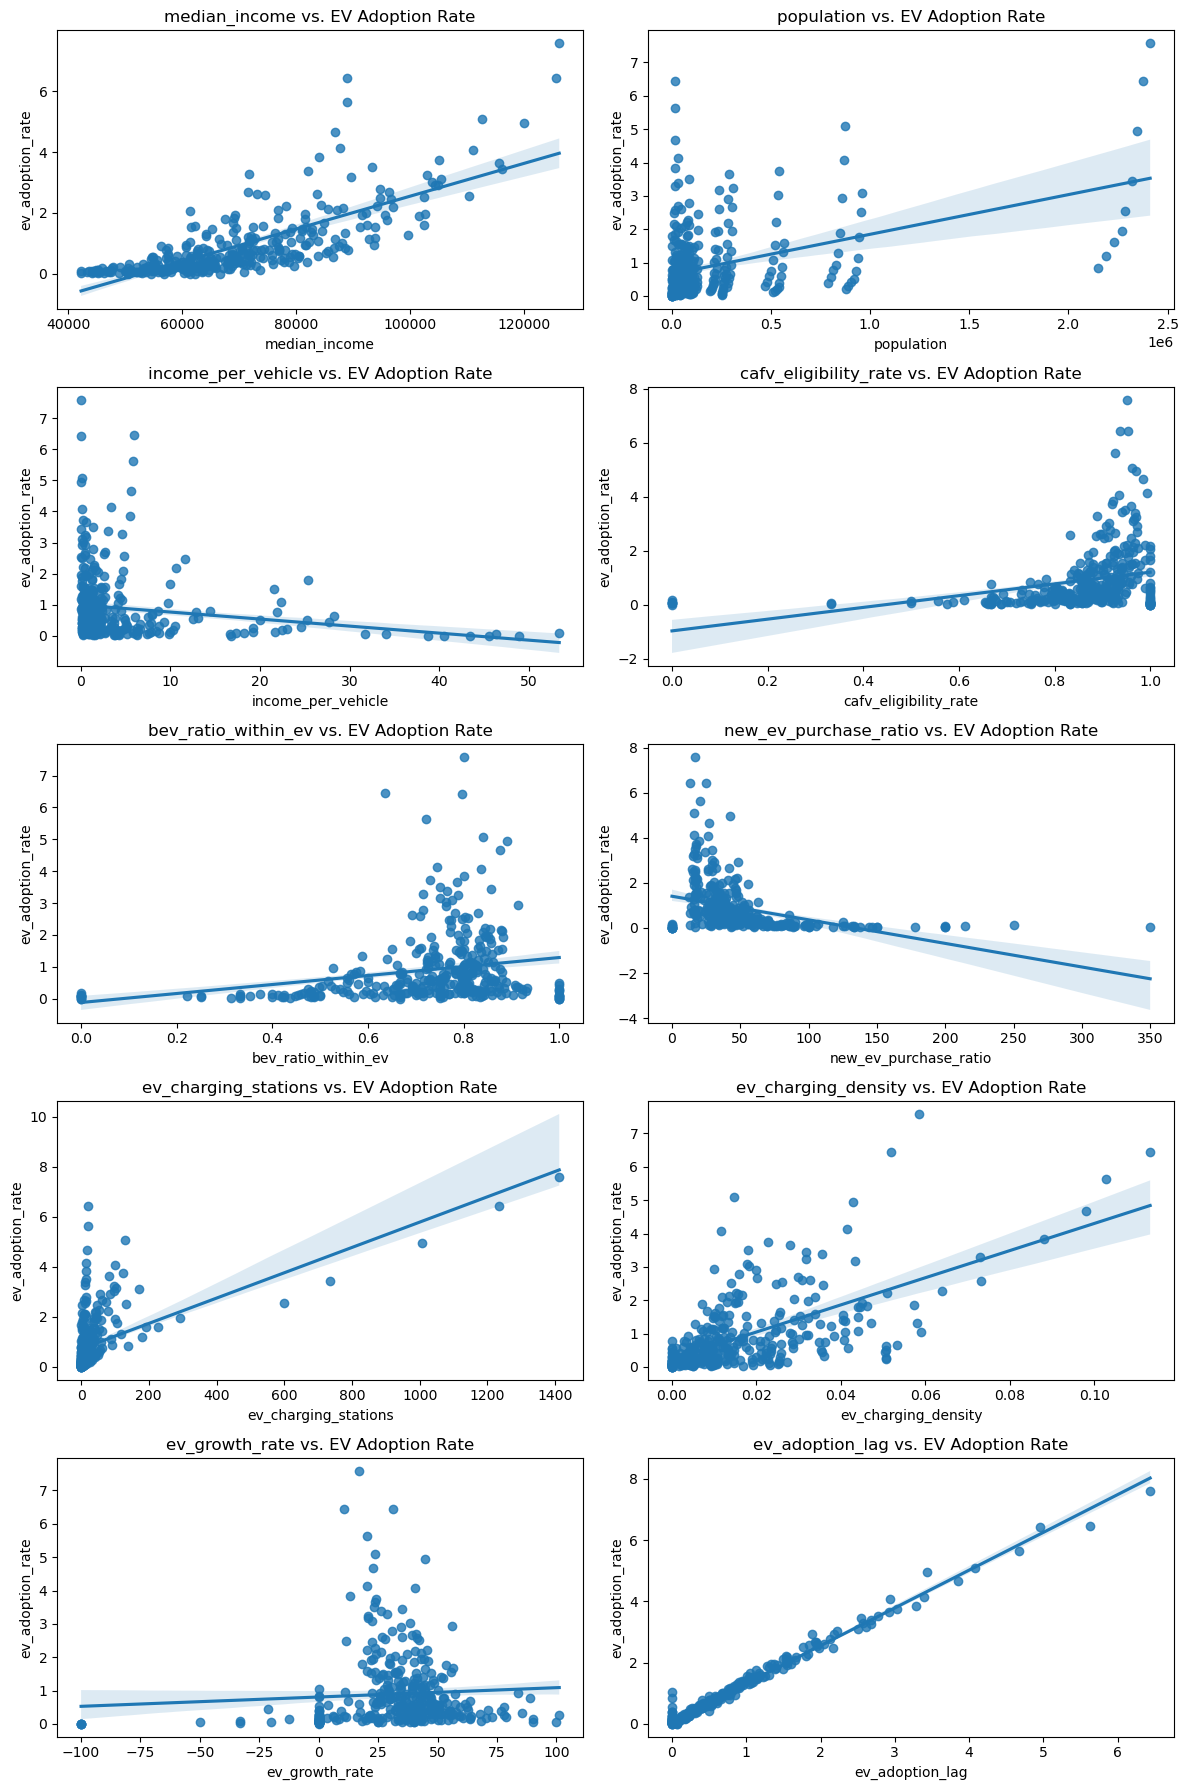

In [10]:
#features vs. ev adoption rate scatter plot
features = ['median_income',
            'population',
            'income_per_vehicle',
            'cafv_eligibility_rate',
            'bev_ratio_within_ev',
            'new_ev_purchase_ratio',
            'ev_charging_stations',
            'ev_charging_density',
            'ev_growth_rate',
            'ev_adoption_lag'
           ]
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 18))
axes = axes.flatten()
for i,col in enumerate(features):
    sns.regplot(data = ev_adoption_df, x = col, y = 'ev_adoption_rate', ax=axes[i])
    axes[i].set_title(f'{col} vs. EV Adoption Rate')  
plt.tight_layout()
image_path_ev_bivariate_distributions = os.path.join(imagepath, 'all_ev_bivariate_distributions.png')
plt.savefig(image_path_ev_bivariate_distributions, dpi = 300, bbox_inches='tight')
plt.show()

##### Strong Positive Predictors
1. Median Income : Income seems to be a strong predictor for EV adoption. As income increases, EV adoption rate increases.
2. Number of EV Charging Stations : It looks like counties with higher EV charging stations also have a higher adoption rate.
3. EV Charging Density : This seems to be highly correlated with ev adoption as well.
4. EV Adoption Lag : This has a very strong positive relationship showing that past EV adoption strongly dictates current adoption, with the vertical drop around 0 capturing the 2017 mean-imputed rows.
##### Moderate Positive Predictors
1. Population : It seems like higher population size also tends to drive EV adoption rate. However, there's quite a bit of vertical clustering for smaller to medium population sizes indicating variance in low to medium population communities regarding ev adoption.
##### Week Positive Predictors
1. EV related variables like cafv_eligibility_rate and bev_share tend to have a weak positive relationship with EV adoption rate indicating these alone are not strong predictors of ev_adoption_rate and sociooeconomic factors, EV charging stations etc. are more influential in determining ev_adoption_rate.
2. EV Growth Rate : There is a weak positive relationship with ev adoption rate. High EV adoption rates are clustered around 20% to 50% annual growth rate, while stagnant or highly volatile markets have close to zero adoption.
##### Features with many anomalies
Both income_per_vehicle and new_ev_purchase ratio plots show a huge data cluster with extreme right-side outliers which tilts the trend lines downward and masks the actual relationship. These features will be dropped from modeling.

#### 3.6.1.3 Time Trends<a id='3.6.1.3_Time_Trends'></a>

##### 3.6.1.3.1 Feature Trends<a id='3.6.1.3.1_Feature_Trends'></a>

All Feature Trends are shown below.

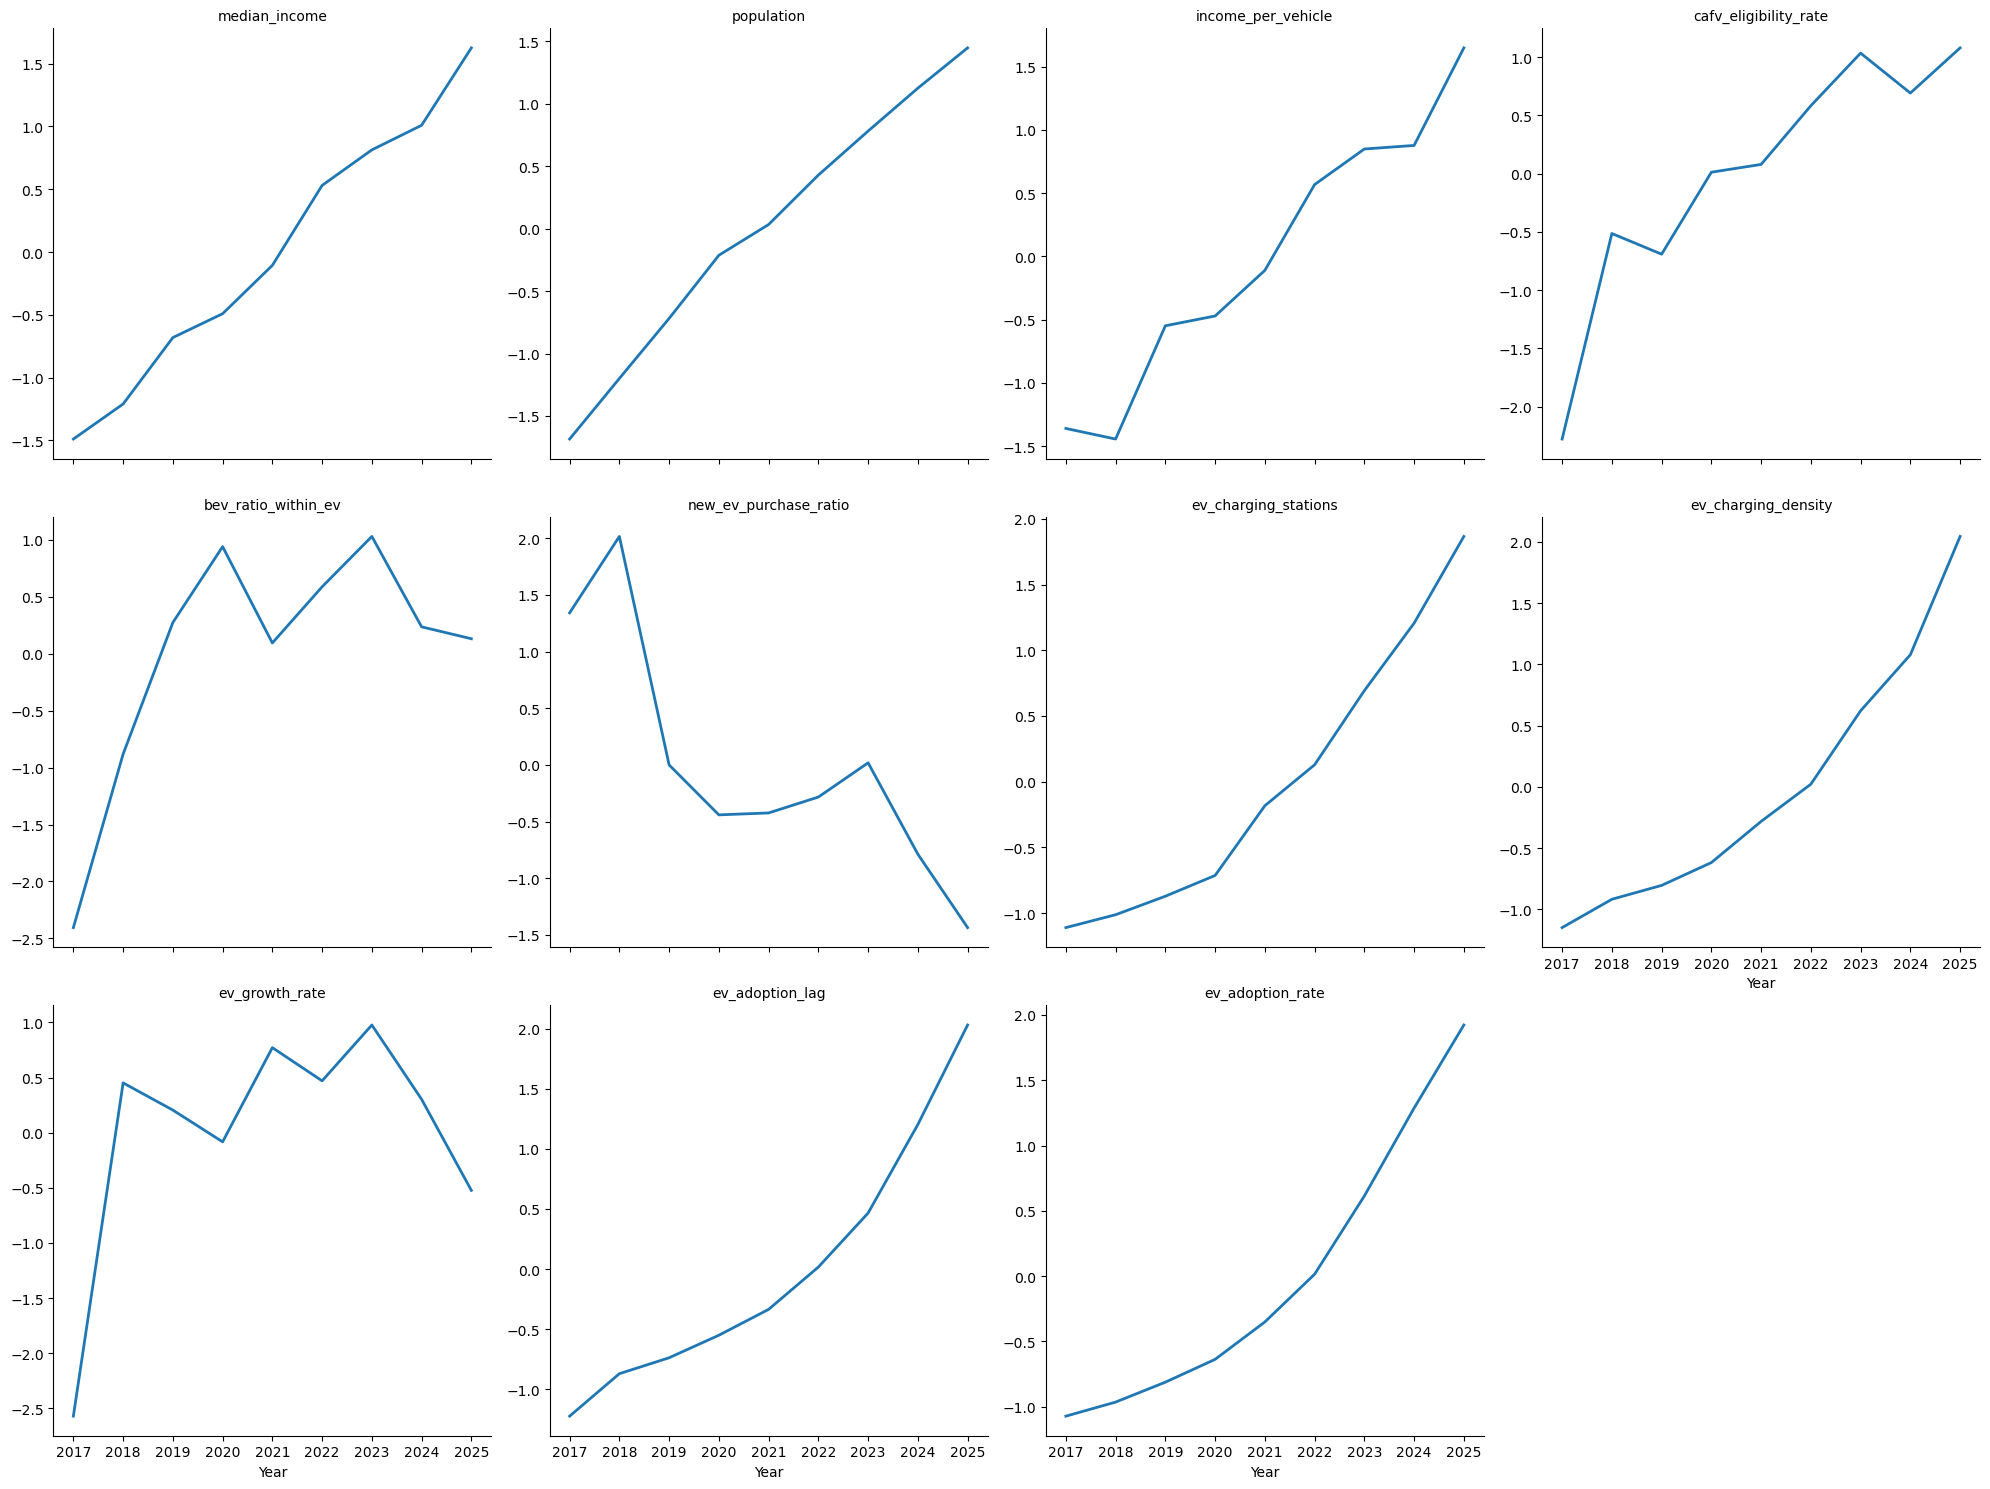

In [11]:
#feature trends from 2017 to 2025 (normalized all features to index = 100 in the starting year)
features = ['median_income',
            'population',
            'income_per_vehicle',
            'cafv_eligibility_rate',
            'bev_ratio_within_ev',
            'new_ev_purchase_ratio',
            'ev_charging_stations',
            'ev_charging_density',
            'ev_growth_rate',
            'ev_adoption_lag',
            'ev_adoption_rate']

ev_trends = ev_adoption_df.groupby('year')[features].mean().reset_index()

scaler = StandardScaler()
ev_scaled = ev_trends.copy()
ev_scaled[features] = scaler.fit_transform(ev_scaled[features])
    
ev_adoption_df_long = ev_scaled.melt(id_vars="year", value_vars=features, var_name="metric", value_name="value")
gd = sns.FacetGrid(ev_adoption_df_long, col="metric", col_wrap=4, sharex = True, sharey = False, height = 5)
gd.map_dataframe(sns.lineplot, x = "year", y = "value", linewidth = 2)

gd.set_titles("{col_name}")
gd.set_axis_labels("Year","")
plt.tight_layout()
image_path_ev_feature_trends = os.path.join(imagepath, 'all_ev_feature_trends.png')
plt.savefig(image_path_ev_feature_trends, dpi = 300, bbox_inches='tight')
plt.show()

1.	Steady Positive Growth: Socioeconomic indicators like median_income, population, & income_per_vehicle show a uniform upward trajectory over time. This reflects the steady economic expansion and rising financial capacity within the state across the years.</p>
2.	Accelerating EV Infrastructure & Adoption: The target variable ev_adoption_rate and ev_adoption_lag show a exponential upward trend. This growth is also reflected in ev_charging_stations and ev_charging_density, indicating a strong link between public infrastructure availability and regional EV adoption.</p>
3.	Policy & EV Mix Maturity: Government policy trackers such as cafv_eligibility_rate and EV vehicle mixes (bev_ratio_within_ev) display strong initial upward momentum before showing signs of stabilizing or fluctuating in more recent years, pointing to a maturing market ecosystem.</p>
4.	Data Quality Artifacts Discovered: The charts highlight two critical data issues. ev_growth_rate suffers from extreme volatility at the absolute start (2017) due to a zero-baseline effect. More importantly, new_ev_purchase_ratio shows a massive, artificial collapse from 2023 to 2025—visually confirming the administrative registration and data-logging lag at the end of the timeline rather than a true economic regression.</p>

##### 3.6.1.3.2 County Trends<a id='3.6.1.3.2_County_Trends'></a>

Top 5 & Bottom 5 County trends are shown below.

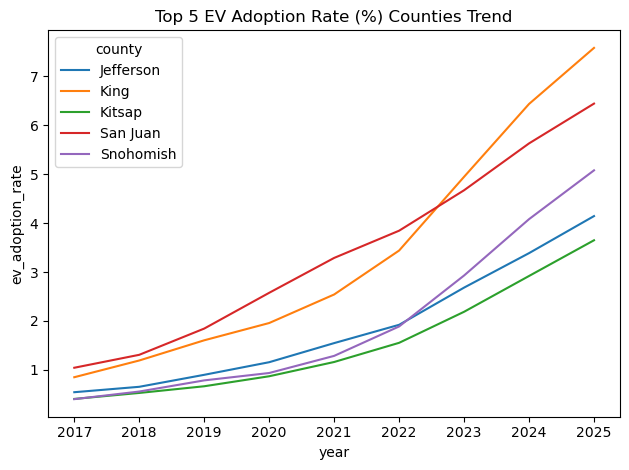

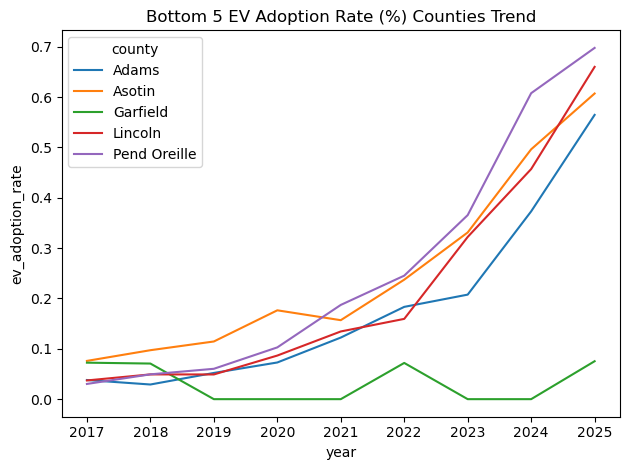

In [26]:
#Top 5
top_counties = ev_adoption_df.groupby('county')['ev_adoption_rate'].mean().nlargest(5).index
sns.lineplot(ev_adoption_df[ev_adoption_df['county'].isin(top_counties)],
             x='year',
             y='ev_adoption_rate',
             hue='county'
            )
plt.title("Top 5 EV Adoption Rate (%) Counties Trend")
plt.tight_layout()
image_path_ev_top_adoption = os.path.join(imagepath, 'all_ev_top_adoption.png')
plt.savefig(image_path_ev_top_adoption, dpi = 300, bbox_inches='tight')
plt.show()
#Bottom 5
bottom_counties = ev_adoption_df.groupby('county')['ev_adoption_rate'].mean().nsmallest(5).index
sns.lineplot(ev_adoption_df[ev_adoption_df['county'].isin(bottom_counties)],
             x='year',
             y='ev_adoption_rate',
             hue='county'
            )
plt.title("Bottom 5 EV Adoption Rate (%) Counties Trend")
plt.tight_layout()
image_path_ev_bottom_adoption = os.path.join(imagepath, 'all_ev_bottom_adoption.png')
plt.savefig(image_path_ev_bottom_adoption, dpi = 300, bbox_inches='tight')
plt.show()

The top 5 vs. bottom 5 counties EV Adoption trends show a huge divide where high ev adoption counties have achieved an exponential momentum while low adoption counties are seeing 0 to extremely low adoption potentially due to low population, lack of income, infrastructure and policies.

#### 3.6.1.4 Correlation Analysis<a id='3.6.1.4_Correlation_Analysis'></a>

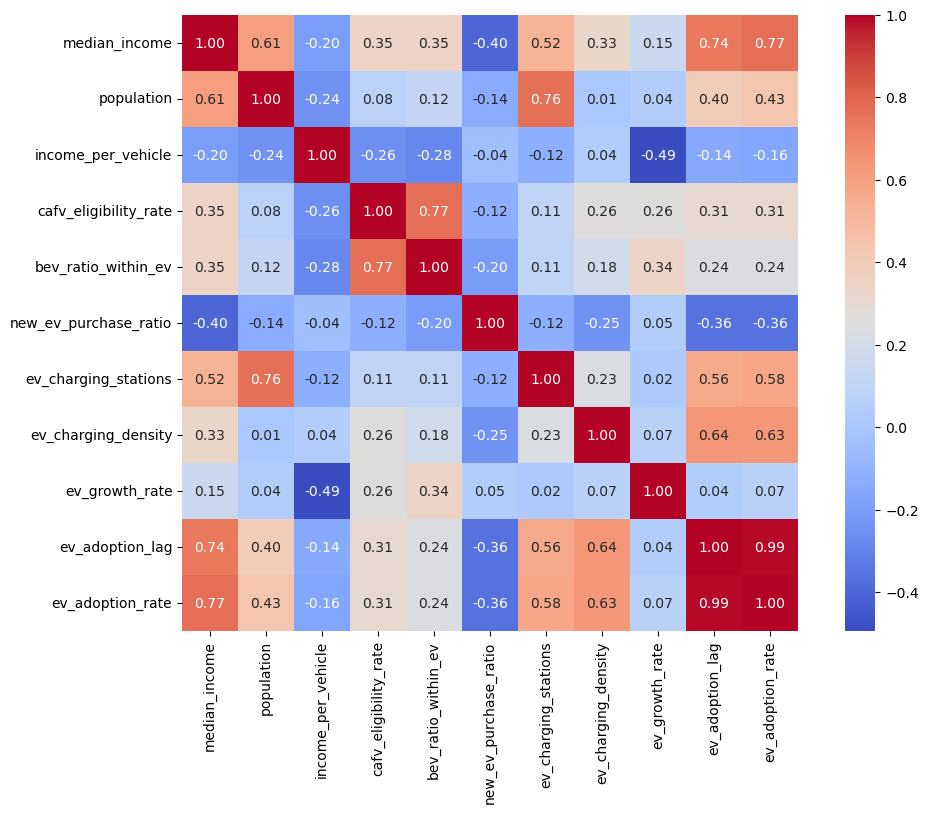

In [13]:
#seaborn heatmap of correlations in ev adoption dataset to assess feature importance for modeling
features = ['median_income',
            'population',
            'income_per_vehicle',
            'cafv_eligibility_rate',
            'bev_ratio_within_ev',
            'new_ev_purchase_ratio',
            'ev_charging_stations',
            'ev_charging_density',
            'ev_growth_rate',
            'ev_adoption_lag',
            'ev_adoption_rate']
ev_adoption_subset = ev_adoption_df[features]
plt.subplots(figsize=(12,8))
sns.heatmap(ev_adoption_subset.corr(), annot = True, cmap = "coolwarm", fmt = ".2f", square = True);
image_path_ev_raw_correlations = os.path.join(imagepath, 'ev_raw_correlations.png')
plt.savefig(image_path_ev_raw_correlations, dpi = 300, bbox_inches='tight')

Lets look at the feature correlation with target variable ev_adoption_rate table below.

In [14]:
print(ev_adoption_subset.corr()['ev_adoption_rate'].sort_values(ascending=False))

ev_adoption_rate         1.000000
ev_adoption_lag          0.992805
median_income            0.767770
ev_charging_density      0.626983
ev_charging_stations     0.576255
population               0.429851
cafv_eligibility_rate    0.309854
bev_ratio_within_ev      0.239825
ev_growth_rate           0.067266
income_per_vehicle      -0.164576
new_ev_purchase_ratio   -0.362125
Name: ev_adoption_rate, dtype: float64


##### Target Variable
•	ev_adoption_rate: The target variable for this study exhibits exponential, compounding upward growth over time and serves as our primary anchor for all correlation metrics.</p>
##### High Performing Predictors
•	ev_adoption_lag (0.99): This is the most powerful predictor in the dataset, exhibiting an almost perfect linear relationship that captures the massive momentum and inertia of historical EV adoption.</p>
•	median_income (0.768): This socio-economic driver shows a strong, clean upward trend alongside adoption, indicating that regional wealth is a primary catalyst for EV adoption.</p>
•	ev_charging_density (0.627): This highly effective infrastructure metric rises exponentially over time, showcasing a tight compounding synergy between localized charger availability and EV adoption.</p>
•	ev_charging_stations (0.576): This EV infrastructure count metric scales positively with adoption, though it remains secondary to density since raw counts are biased by county size.</p>
•	population (0.430): This steadily increasing macro baseline correlates moderately with adoption, though its highly right-skewed distribution will require a log transformation for linear models.</p>

##### Weakly Correlated Features
•	cafv_eligibility_rate (0.310): This policy tracker seems to be weakly correlated with ev adoption rate.</p>
•	bev_ratio_within_ev (0.240): This vehicle-mix metric also seems to have a very weak positive correlation with ev adoption rate.</p>
•	ev_growth_rate (0.067): This is a weakly correlated, bimodal indicator showing that high adoption thrives on stable, compounding 20% to 50% annual growth, while stagnant markets flatten out at zero.</p>
•	income_per_vehicle (-0.165): This ratio is highly distorted and creates a false negative correlation because tiny vehicle counts in rural counties create massive, artificial outlier spikes that warp the regression slope.</p>
•	new_ev_purchase_ratio (-0.362): This heavily biased feature exhibits a false negative correlation due to severe reporting lags and incomplete data-logging cycles at the tail end of the timeline (2024–2025).</p>

We will not consider these very weakly correlated features for our model feature set.

#### 3.6.1.5 Segmentation Analysis<a id='3.6.1.4_Segmentation_Analysis'></a>

High Vs. Low Adoption Region Key Differentiators

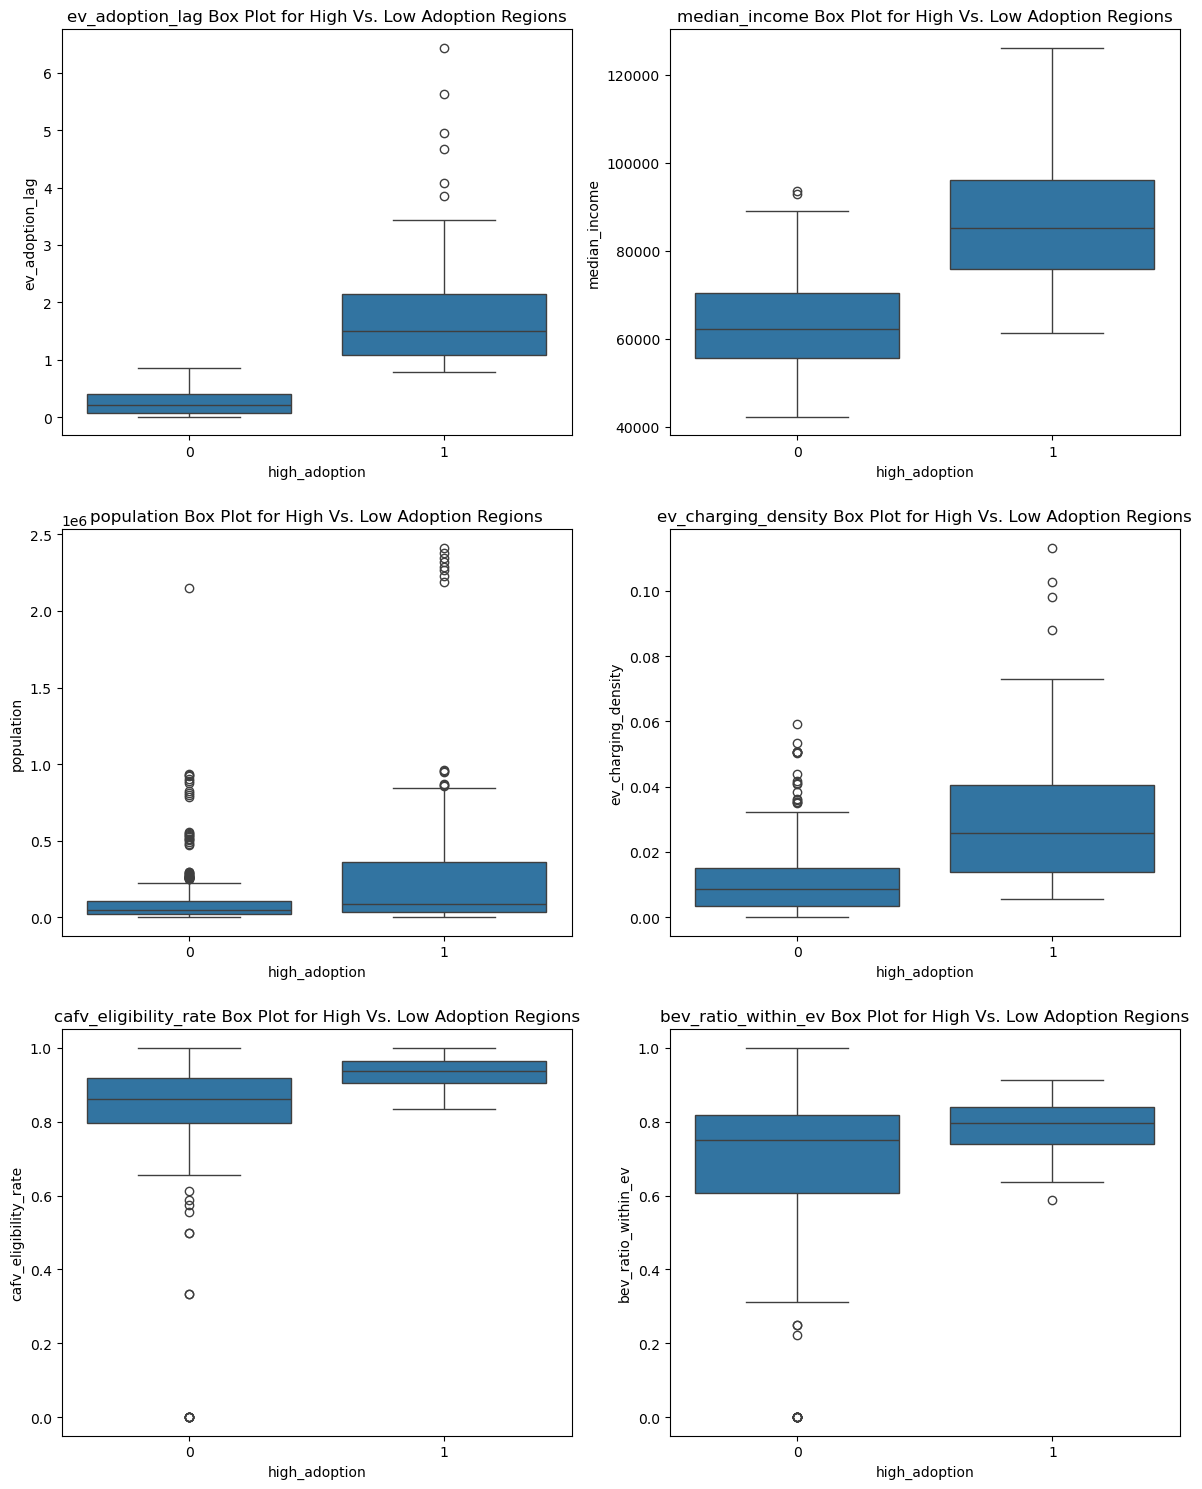

In [15]:
features = ['ev_adoption_lag',
            'median_income',
            'population',
            'ev_charging_density',
            'cafv_eligibility_rate',
            'bev_ratio_within_ev'
           ]
fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 15))
axes = axes.flatten()
for i,col in enumerate(features):
    sns.boxplot(data = ev_adoption_df,  x='high_adoption', y = col, ax=axes[i])
    axes[i].set_title(f'{col} Box Plot for High Vs. Low Adoption Regions')  
plt.tight_layout()
image_path_segmentation_box_plots = os.path.join(imagepath, 'ev_segmentation_box_plots.png')
plt.savefig(image_path_segmentation_box_plots, dpi = 300, bbox_inches='tight')
plt.show()

The boxplots reveal a clear socio-economic divide where high-adoption regions are clearly separated by higher median incomes, charging station densities, and historical adoption momentum, while highlighting extreme population outliers and the heavy visual redundancy of the vehicle-mix features such as cafv_eligibility_rate & bev_ratio_within_ev (showing compressed, high-positioned medians for high-adoption zones).

#### 3.5.1.6 Multicollinearity Check<a id='3.5.1.4_Multicollinearity_Check'></a>

Let's do a formal multicollinearity check in this section to see if our key features have high multicollinearity.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = ['median_income', # Strongest demographic predictor (0.767)
        'population', # Captures county scale/size
        'ev_charging_density', # Strong infrastructure proxy
        'ev_adoption_lag', # Strongest momentum predictor (0.967)
        'lag_missing_flag' # Crucial 2017 adoption lag missing flag to inform models
       ]

vif = ev_adoption_df[cols].dropna()

ev_adoption_vif = pd.DataFrame()
ev_adoption_vif["feature"] = vif.columns
ev_adoption_vif["VIF"] = [variance_inflation_factor(vif.values, i) for i in range(len(vif.columns))]

ev_adoption_vif

,feature,VIF
0,median_income,3.117392
1,population,1.822219
2,ev_charging_density,3.490792
3,ev_adoption_lag,3.710264
4,lag_missing_flag,1.167358


We have low multicollinearity for all these features so these should be good to use with some transformations.

Next, we will do some checks and create a model ready dataset.

#### 3.5.2.5 Model Readiness Checks<a id='3.5.2.5_Model_Readiness_Checks'></a>

In this final section, we will assess the ev adoption dataset at county/year level again to make sure it is ready for modeling.

In [17]:
#dropping redundant and weakly correlated features
ev_modeling_df = ev_adoption_df.drop(columns=[ 'total_registered_vehicles',  
                                              'registered_electric_vehicles', 
                                              'bev_ratio_within_ev',
                                              'cafv_eligibility_rate',
                                              'ev_charging_stations',
                                              'ev_growth_rate',
                                              'has_growth',
                                              'new_ev_purchase_ratio',
                                              'income_per_vehicle',
                                              'high_adoption',
                                              'adoption_segment' ])

In [18]:
ev_modeling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         351 non-null    int64  
 1   county                       351 non-null    object 
 2   median_income                351 non-null    int64  
 3   population                   351 non-null    int64  
 4   ev_adoption_rate             351 non-null    float64
 5   ev_adoption_lag              351 non-null    float64
 6   lag_missing_flag             351 non-null    int64  
 7   ev_charging_density          351 non-null    float64
 8   has_charging_infrastructure  351 non-null    int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 24.8+ KB


In [19]:
ev_modeling_df.isna().sum()

year                           0
county                         0
median_income                  0
population                     0
ev_adoption_rate               0
ev_adoption_lag                0
lag_missing_flag               0
ev_charging_density            0
has_charging_infrastructure    0
dtype: int64

In [20]:
ev_modeling_df.duplicated().sum()

np.int64(0)

Modeling Dataset looks complete without duplicate or nulls.

We previously saw that most of our core features of population, ev_charging_density, ev_adoption_lag, median income & target variable ev_adoption_rate were right skewed to varying degrees. Let us do a log transform on these features and then quickly check the correlations, features and multicollinearity to see if we can use log transformations of these features for modeling.

In [21]:
#creating columns with log transforms on core features for modeling
ev_modeling_df['log_population']=np.log1p(ev_modeling_df['population'])
ev_modeling_df['log_median_income']=np.log1p(ev_modeling_df['median_income'])
ev_modeling_df['log_ev_charging_density']=np.log1p(ev_modeling_df['ev_charging_density'])
ev_modeling_df['log_ev_adoption_lag']=np.log1p(ev_modeling_df['ev_adoption_lag'])
ev_modeling_df['log_ev_adoption_rate']=np.log1p(ev_modeling_df['ev_adoption_rate'])

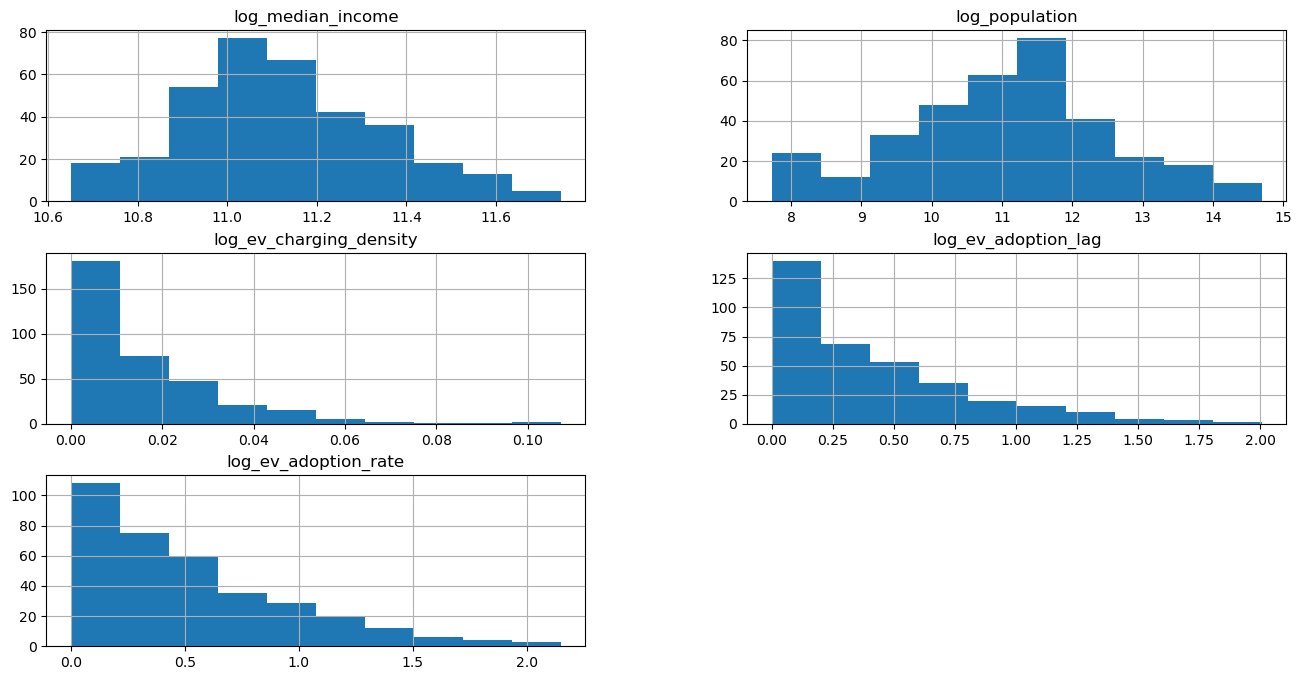

In [22]:
#lets look at the distributions after log transforms
_=ev_modeling_df[['log_median_income',
                  'log_population',
                  'log_ev_charging_density',
                  'log_ev_adoption_lag',
                  'log_ev_adoption_rate'
                 ]].hist(figsize=(16,8))

log_ev_charging_density, log_ev_adoption_lag and log_ev_adoption_rate are still right skewed distributions. Let us try another transformation yeo-johnson to see if it improves our feature distributions.

In [23]:
pt = PowerTransformer(method = 'yeo-johnson')

#creating columns with 'yeo-johnson' transforms on core features for modeling
ev_modeling_df[['yj_population']]=pt.fit_transform(ev_modeling_df[['population']])
ev_modeling_df[['yj_median_income']]=pt.fit_transform(ev_modeling_df[['median_income']])
ev_modeling_df[['yj_ev_charging_density']]=pt.fit_transform(ev_modeling_df[['ev_charging_density']])
ev_modeling_df[['yj_ev_adoption_lag']]=pt.fit_transform(ev_modeling_df[['ev_adoption_lag']])
ev_modeling_df[['yj_ev_adoption_rate']]=pt.fit_transform(ev_modeling_df[['ev_adoption_rate']])

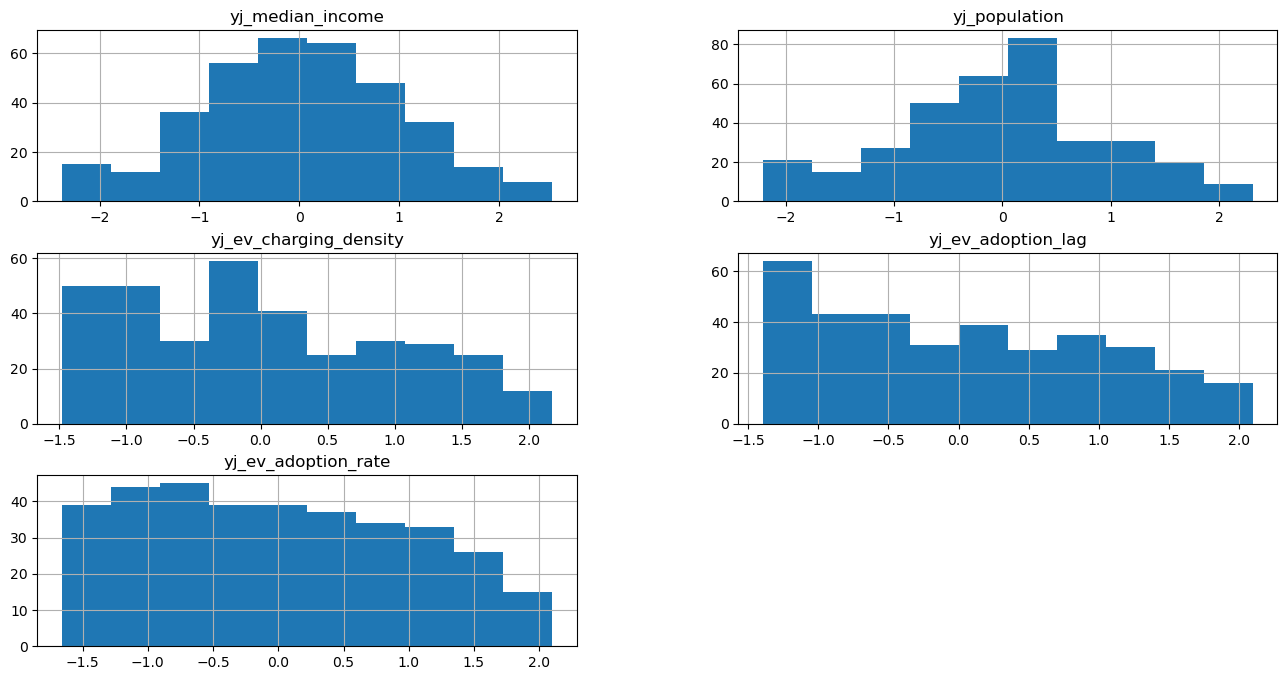

In [24]:
#lets look at the distributions after log transforms
_=ev_modeling_df[['yj_median_income',
                  'yj_population',
                  'yj_ev_charging_density',
                  'yj_ev_adoption_lag',
                  'yj_ev_adoption_rate'
                 ]].hist(figsize=(16,8))
image_path_yj_transformed_dists = os.path.join(imagepath, 'yj_transformed_distributions.png')
plt.savefig(image_path_yj_transformed_dists, dpi = 300, bbox_inches='tight')

The updated yj transformation made the right skewed distributions more uniform however we still did not get a normal distribution for ev_charging_density, ev_adoption_lag and ev_adoption_rate. 

1. yj_ev_adoption_rate (Target): It forms a uniform "block" with a tapered right tail because our dataset has a massive, steady baseline of lower-adoption county-years with a distinct, gradual tapering of high-growth tech hubs.
2. yj_ev_charging_density: It features a tall block on the far left followed by a distinct sharp peak right before zero, because it separates the absolute zero-infrastructure counties from a large cluster of counties with minimal, baseline charging networks.
3. yj_ev_adoption_lag: It shows a step-down plateau with a heavy left wall because a massive volume of records sit at the zero-adoption baseline, while the remaining county-years trail off smoothly as they scale up.

These distributions should work for Ridge Regression Model because

1. Normality applies to errors, not inputs: Linear regression math only requires the prediction errors (residuals) to be normally distributed, so having a blocky target or plateaued features will not violate our model assumptions.
2. Outliers are gone, stabilizing the model: The Yeo-Johnson transformation successfully pulled in the extreme, long-tailed outliers that would typically warp a regression line, bounding all data between a manageable -1.5 and 2.5 range.
3. Ridge regularization handles non-normal variance: Because we are planning on using Ridge Regression given the dataset size( only 351 records), its built-in L2 penalty automatically shrinks feature coefficients, safely preventing dense data clusters or flat plateaus from destabilizing the model's weights.

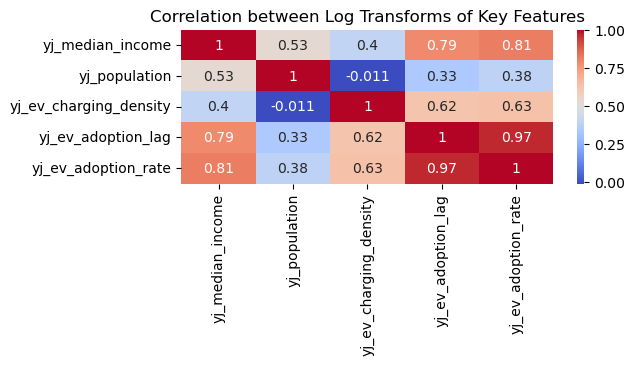

In [25]:
#quick correlations check for 1st feature set (to model ev adoption rate)
#heatmap for core features
corr_matrix_log=ev_modeling_df[['yj_median_income',
                          'yj_population',
                          'yj_ev_charging_density',
                          'yj_ev_adoption_lag',
                          'yj_ev_adoption_rate'
                         ]].corr()
plt.figure(figsize=(6,2))
sns.heatmap(corr_matrix_log, annot=True, cmap='coolwarm')
plt.title("Correlation between Log Transforms of Key Features")
image_path_yj_transformed_corr = os.path.join(imagepath, 'yj_transformed_correlations.png')
plt.savefig(image_path_yj_transformed_corr, dpi = 300, bbox_inches='tight')
plt.show()

Correlations are still the same for these features after log transformations. Let us do a quick multicollinearity check.

In [26]:
cols = ['yj_median_income', # Strongest demographic predictor (0.767)
 # Captures county scale/size
        'yj_population',
        'yj_ev_charging_density', # Strong infrastructure proxy
        'yj_ev_adoption_lag', # Strongest momentum predictor (0.967)
        'lag_missing_flag', # Crucial 2017 adoption lag missing flag to inform models
        'has_charging_infrastructure' #Important for handling 0 floor clusters
       ]

vif = ev_modeling_df[cols].dropna()

ev_modeling_vif = pd.DataFrame()
ev_modeling_vif["feature"] = vif.columns
ev_modeling_vif["VIF"] = [variance_inflation_factor(vif.values, i) for i in range(len(vif.columns))]

ev_modeling_vif

,feature,VIF
0,yj_median_income,3.300799
1,yj_population,1.564675
2,yj_ev_charging_density,1.858837
3,yj_ev_adoption_lag,4.202915
4,lag_missing_flag,1.523041
5,has_charging_infrastructure,1.211554


All VIF values are <4.3 indicating low multicollinearity. This is good news as we can keep all these features for modeling.

We will finalize these as our core features for modeling and create a model ready dataset next.

In [27]:
#lets drop redundant columns
ev_modeling_df = ev_modeling_df.drop(columns=['population','log_population','ev_charging_density','median_income','ev_adoption_lag','ev_adoption_rate',
                                              'log_median_income','log_ev_charging_density','log_ev_adoption_lag','log_ev_adoption_rate'])

In [28]:
ev_modeling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         351 non-null    int64  
 1   county                       351 non-null    object 
 2   lag_missing_flag             351 non-null    int64  
 3   has_charging_infrastructure  351 non-null    int64  
 4   yj_population                351 non-null    float64
 5   yj_median_income             351 non-null    float64
 6   yj_ev_charging_density       351 non-null    float64
 7   yj_ev_adoption_lag           351 non-null    float64
 8   yj_ev_adoption_rate          351 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 24.8+ KB


In [29]:
# save model data to a new csv file
datapath = '../data/processed'
save_file(ev_modeling_df, 'ev_model_ready_data.csv', datapath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../data/processed\ev_model_ready_data.csv"


## 3.7 Summary<a id='3.7_Summary'></a>

Below are some key takeaways from the exploratory data analysis done in this section for our EV Adoption dataset.</p>
###### • 3.6.1.1 Univariate Analysis: 
Multiplying fractional values by 100 before running np.log1p successfully pulled ev_charging_density out of its decimal log trap into a normal distribution. All other key features and target variable except lag_missing_flag were log transformed to ensure more linear relationships and normal distribution for Linear Regression analysis (log_median_income, log_ev_adoption_lag, log_ev_charging_density, log_ev_adoption_rate).</p>
###### • 3.6.1.2 Bivariate Analysis: 
Tiny rural counties with very few vehicles created massive, artificial spikes for income_per_vehicle and new_ev_purchase_ratio, drawing a misleading downward trend line that hid the real positive power of household income.</p>
###### • 3.6.1.3 Time Trends: 
High income counties saw rapid adoption after 2020, while our new_ev_purchase_ratio suffered an artificial crash at the very end of the timeline because the state database has heavy lags when logging brand-new vehicle registrations.</p>
###### • 3.6.1.4 Correlation Analysis:  
Previous year's market momentum (log_ev_adoption_lag) proved to be the strongest predictor with a near-perfect 0.99 correlation, followed closely by log median income at 0.8 and log EV charging stations density at 0.63.</p>
###### • 3.6.1.5 Segmentation Analysis: 
Dividing counties by adoption tiers confirmed a strict financial divide: higher income acts as a gateway to start buying EVs, but having a higher charging stations density is what drives long-term market growth.</p>
###### • 3.6.1.6 Model Readiness: 
Dropping population and cafv_eligibility_rate, bev_ratio_within_ev eliminated the overlapping linear noise between large cities and high income, instantly bringing down all remaining feature VIF scores below 5.2.</p>